In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [2]:
# load the data
data = pd.read_csv('diabetes_dataset.csv')

In [3]:
data.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

##### As Per The EDA Droping Fertures that has high correlation.

a) Cholesterol features

ldl_cholesterol and cholesterol_total correlation = 0.91 → redundant.

Drop one (e.g., cholesterol_total) because ldl_cholesterol is more specific.

b) BMI and Waist-to-Hip Ratio

Correlation = 0.77 → high correlation.

Drop one (commonly bmi if waist-to-hip ratio is more predictive for cardiovascular risk).

c) HBA1c and Insulin Level

Correlation = 0.70 → moderate.

Can keep both, as they provide complementary info for diabetes prediction.

d) Diabetes Risk Score

If you are predicting diabetes, this feature may leak the target, because it’s derived from other features.

Drop diabetes_risk_score if predicting diagnosed_diabetes.

In [4]:
#Remove any Higly correlated features as per EDA analysis
data = data.drop(columns=['diabetes_stage','diabetes_risk_score','cholesterol_total','bmi'])
    

Removing highly correlated features reduces multicollinearity, which improves model stability for linear models.
For tree-based models, it’s less critical, but still helps reduce noise and improves interpretability.


#### Spliit Data to  train on one part and test on unseen data.

In [5]:
# Spliit Data to  train on one part and test on unseen data.
X = data.drop('diagnosed_diabetes', axis=1)
y = data['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Try to Exacute Decion Tree with out Encoding data since Trees Algorithms Trees split data based on thresholds so they do not assume numeric order.}

In [6]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

ValueError: could not convert string to float: 'Female'

Evan though Tree algorthms like [Decision Tree / Random Forest] not needed to encode catagorical fertures to numarical since using scikit-learn we  must still need to  convert categorical text into  numbers

#### One Hot Encode Data

In [7]:
## One Hot Encode Data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

##### Decision Tree Clasifier

In [8]:
## Decision Tree Classifier with Encoded Data
dt_classifier_encoded = DecisionTreeClassifier(random_state=42)
dt_classifier_encoded.fit(X_train_encoded, y_train)
y_pred_dt_encoded = dt_classifier_encoded.predict(X_test_encoded)
print("Decision Tree Classifier with Encoded Data Accuracy:", accuracy_score(y_test, y_pred_dt_encoded))
print(classification_report(y_test, y_pred_dt_encoded))

Decision Tree Classifier with Encoded Data Accuracy: 0.86295
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      8000
           1       0.88      0.89      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



Confusion Matrix:
 [[ 6548  1452]
 [ 1289 10711]]


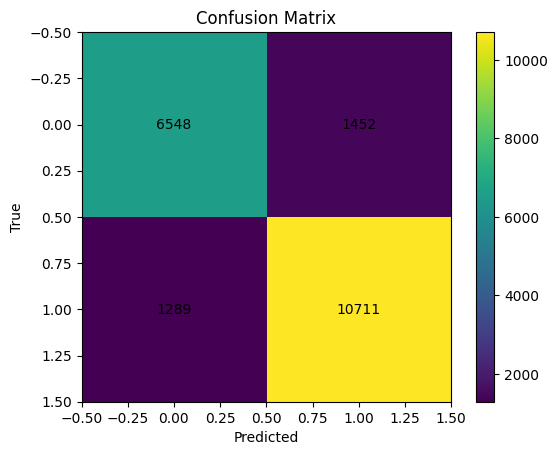

In [9]:
# Decision Tree Confusion Metrics
cm = confusion_matrix(y_test,y_pred_dt_encoded)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

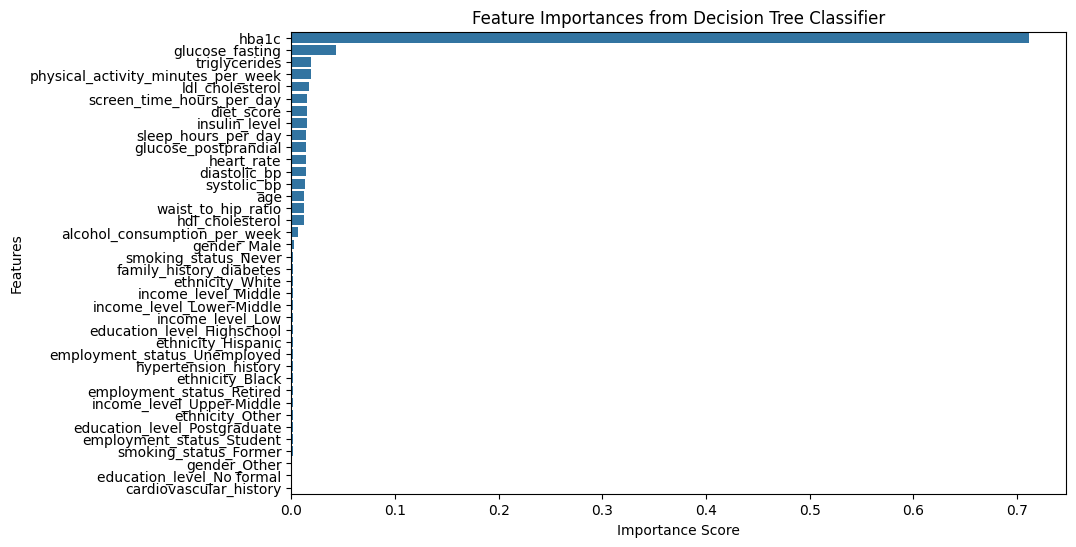

In [10]:
# Decision Tree Ferture Importance
feature_importances = pd.Series(dt_classifier_encoded.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Random Forest Classifier

In [11]:
## Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_encoded, y_train)
y_pred_rf = rf_classifier.predict(X_test_encoded)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.9196
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 7994     6]
 [ 1602 10398]]


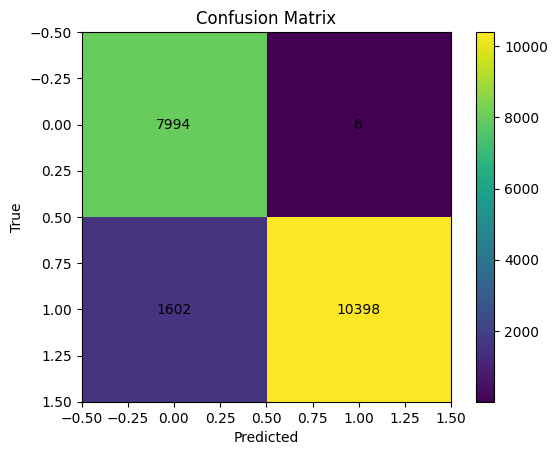

In [12]:
# Random Forest Confusion Metrics
cm = confusion_matrix(y_test,y_pred_rf)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

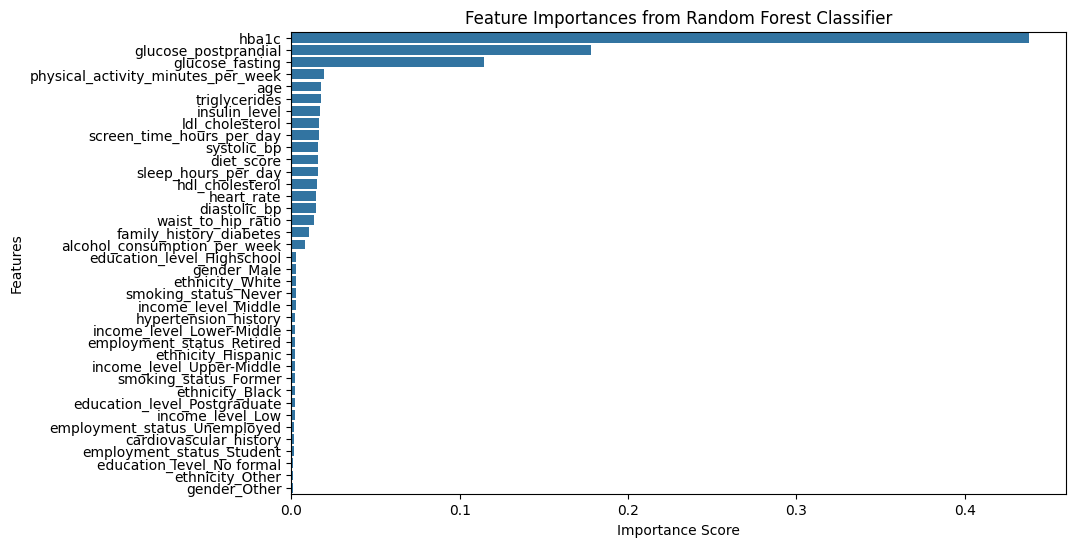

In [13]:
# random forest feature importance
rf_feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_encoded.columns)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_feature_importances, y=rf_feature_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

All features are now on the same scale (mean=0, std=1), so no feature dominates because of large numbers. This step is importan for modules like Logistic Regression & Gradian Boosting /XGBoost  wich that rely on distance/gradients perform better.

### Gradian Boosting Classifier?

In [15]:
# Gradian Boosting Clasifier 
# Initialize the Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,   # Number of boosting stages
    learning_rate=0.1,  # Step size shrinkage
    max_depth=3,        # Maximum depth of individual estimators
    random_state=42
)

# Fit the model
gb_clf.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_gb = gb_clf.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", accuracy)
# Get predicted probabilities for the positive class
y_prob_gb = gb_clf.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, y_prob_gb)
print("ROC AUC Score:", roc_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy: 0.9199
ROC AUC Score: 0.9447343020833333

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 8000     0]
 [ 1602 10398]]


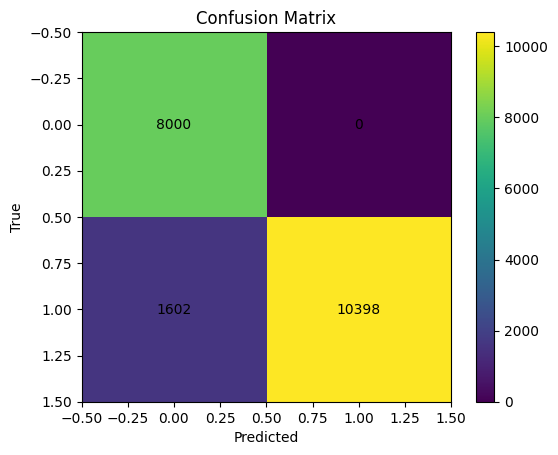

In [16]:
# Gradiant Confusion Metrics
cm = confusion_matrix(y_test,y_pred_gb)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

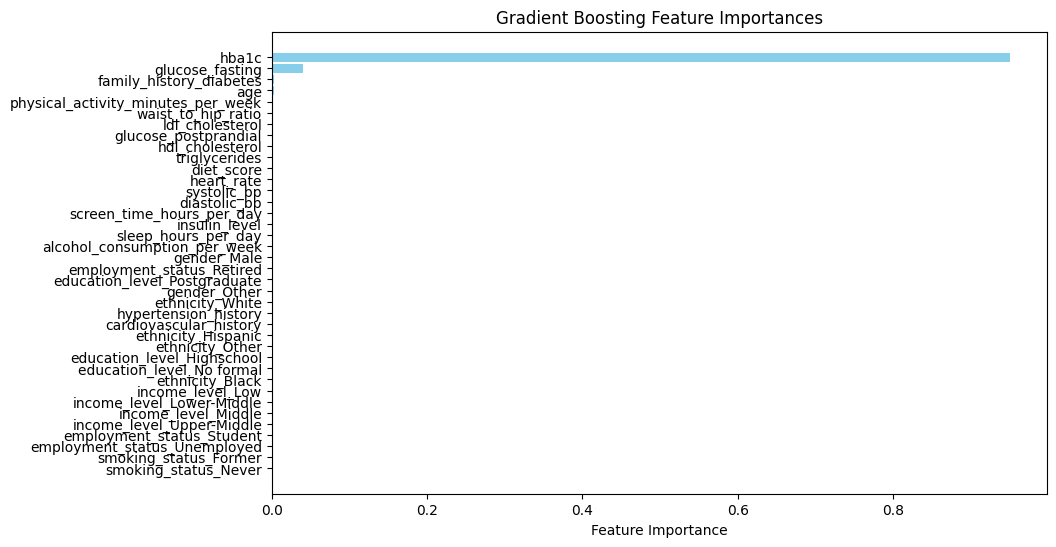

In [17]:
# Get feature importances from the model
feature_importances_gb = gb_clf.feature_importances_

# Map feature importances to feature names
features = X_train_encoded.columns
importance_df_gb = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances_gb
})

# Sort features by importance
importance_df_gb = importance_df_gb.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df_gb['Feature'], importance_df_gb['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importances')
plt.show()

#### Logistic Regression Classifier 

In [19]:
## Logistic Regression Classifier
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled, y_train)
y_pred_logreg = logreg_classifier.predict(X_test_scaled)
print("Logistic Regression Classifier Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Classifier Accuracy: 0.86045
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



Confusion Matrix:
 [[ 6470  1530]
 [ 1261 10739]]


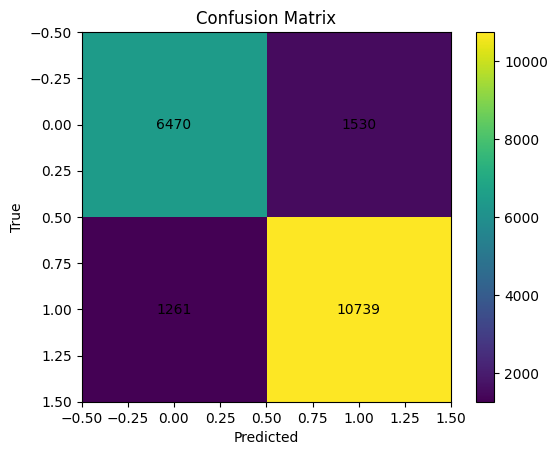

In [20]:
# Logistic Regression Confusion Metrics
cm = confusion_matrix(y_test,y_pred_logreg)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

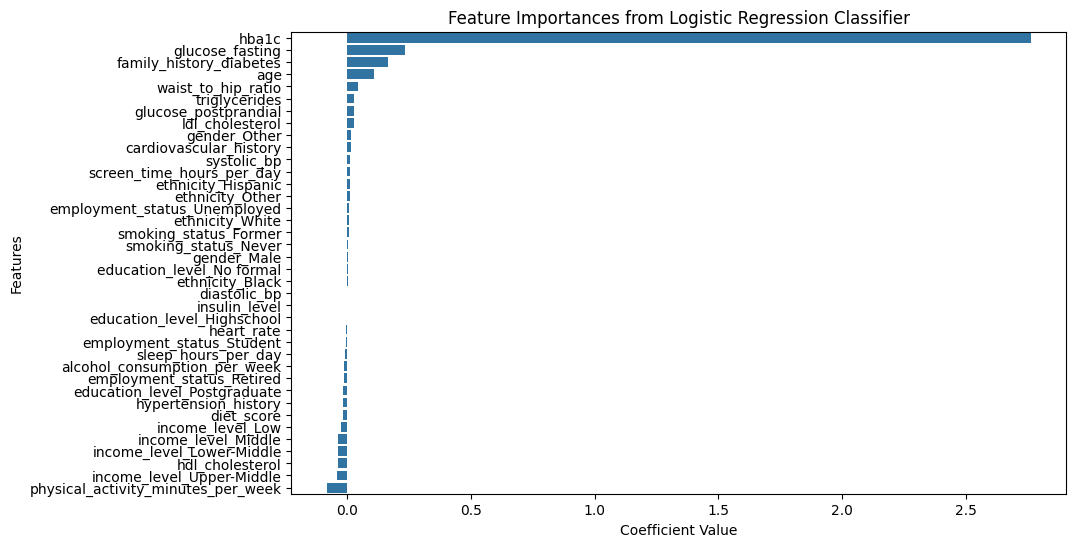

In [21]:
## logistic regression feature importance
logreg_feature_importances = pd.Series(logreg_classifier.coef_[0], index=X_train_encoded.columns)
logreg_feature_importances = logreg_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=logreg_feature_importances, y=logreg_feature_importances.index)
plt.title('Feature Importances from Logistic Regression Classifier')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

#### XGBoost using For high Accuracy 

In [22]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 31.8 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 31.4 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [23]:
import xgboost as xgb
from xgboost import XGBClassifier


In [24]:
xgb_model = XGBClassifier(
    objective='binary:logistic',   # binary classification
    eval_metric='logloss',         # required to avoid warnings
    n_estimators=300,              # number of trees
    learning_rate=0.05,            # shrinkage
    max_depth=5,                   # depth of trees
    subsample=0.8,                 # row sampling
    colsample_bytree=0.8,          # feature sampling
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1] 

In [25]:
# XGBoost Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9199
Precision: 1.0
Recall: 0.8665
F1 Score: 0.9284757567639967
ROC AUC: 0.9432060625

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 8000     0]
 [ 1602 10398]]


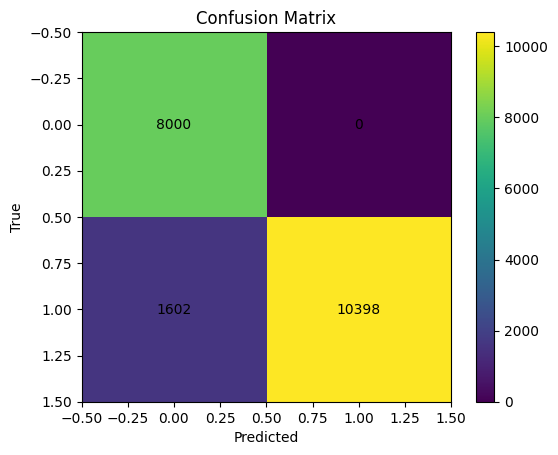

In [26]:
# Confussion metrics
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

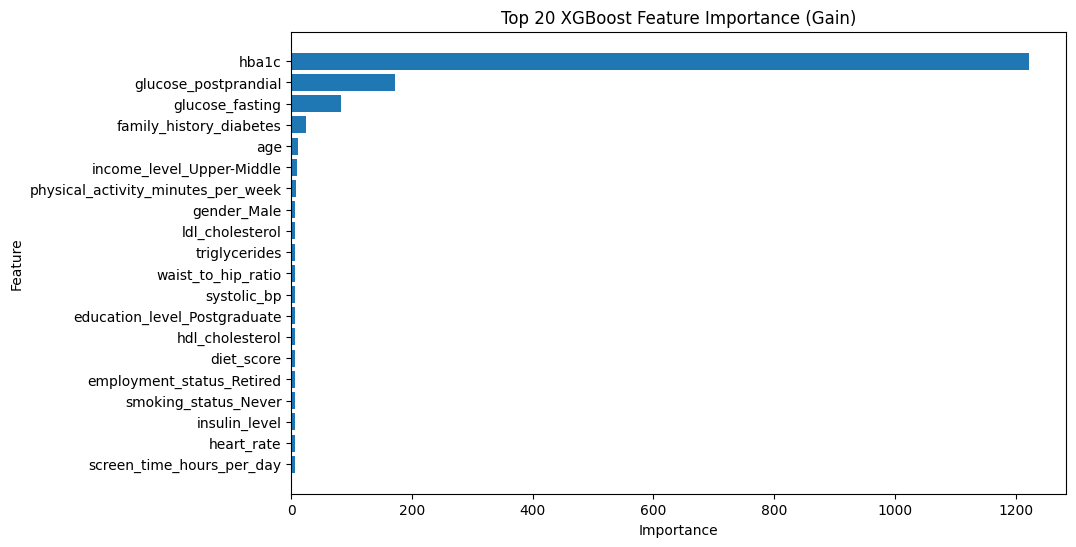

In [27]:
# XGBoost Ferture Importance 
# Get actual feature names
feature_names = X_train_encoded.columns

# Get raw importance dictionary from XGBoost
score_dict = xgb_model.get_booster().get_score(importance_type='gain')

# Convert XGBoost f0/f1/f2... into real feature names
mapped_scores = {
    feature_names[int(k[1:])]: v   # remove "f" and convert index -> real column name
    for k, v in score_dict.items()
}

# Create DataFrame
df_imp = pd.DataFrame({
    "feature": list(mapped_scores.keys()),
    "importance": list(mapped_scores.values())
})

# Sort & get top 20
df_imp = df_imp.sort_values(by="importance", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.title("Top 20 XGBoost Feature Importance (Gain)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Final Model Selection For The Given Data

In [28]:
# Model Comparison
models = {
    'Decision Tree': accuracy_score(y_test, y_pred_dt_encoded),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'GradientBoost':accuracy_score(y_test, y_pred_gb),
    'Logistic Regression': accuracy_score(y_test, y_pred_logreg),
    'XgBoost':accuracy_score(y_test, y_pred)
    
}
print("Model Comparison (Accuracy Scores):")
for model, accuracy in models.items():
    print(f"{model}: {accuracy:.4f}")

Model Comparison (Accuracy Scores):
Decision Tree: 0.8629
Random Forest: 0.9196
GradientBoost: 0.9199
Logistic Regression: 0.8605
XgBoost: 0.9199


In [29]:
# Model Comparison Usinfg F1 Score
from sklearn.metrics import f1_score
f1_scores = {
    'Decision Tree': f1_score(y_test, y_pred_dt_encoded),
    'Random Forest': f1_score(y_test, y_pred_rf),
    'GradientBoost':f1_score(y_test, y_pred_gb),
    'Logistic Regression': f1_score(y_test, y_pred_logreg),
    'XgBoost':f1_score(y_test, y_pred)
}
print("\nModel Comparison (F1 Scores):")
for model, f1 in f1_scores.items():
    print(f"{model}: {f1:.4f}")


Model Comparison (F1 Scores):
Decision Tree: 0.8866
Random Forest: 0.9282
GradientBoost: 0.9285
Logistic Regression: 0.8850
XgBoost: 0.9285


In [30]:
# Model Comparison Using ROC AUC Score
roc_auc_scores = {
    'Decision Tree': roc_auc_score(y_test, dt_classifier_encoded.predict_proba(X_test_encoded)[:,1]),
    'Random Forest': roc_auc_score(y_test, rf_classifier.predict_proba(X_test_encoded)[:,1]),
    'GradientBoost': roc_auc_score(y_test, gb_clf.predict_proba(X_test_scaled)[:, 1]),
    'Logistic Regression': roc_auc_score(y_test, logreg_classifier.predict_proba(X_test_scaled)[:,1]),
    'XgBoost':roc_auc_score(y_test, y_proba)
}
print("\nModel Comparison (ROC AUC Scores):")
for model, roc_auc in roc_auc_scores.items():
    print(f"{model}: {roc_auc:.4f}")


Model Comparison (ROC AUC Scores):
Decision Tree: 0.8555
Random Forest: 0.9410
GradientBoost: 0.9447
Logistic Regression: 0.9338
XgBoost: 0.9432


In [31]:
# Convert XGBoost importance DataFrame to Series if needed
xg_top = df_imp.set_index('feature')['importance']

# Convert Gradient Boosting importance to Series if needed
gb_top = pd.Series(gb_clf.feature_importances_, index=X_train_encoded.columns)

# Take top 10 from each
top_n = 10
lr_top = logreg_feature_importances.sort_values(ascending=False).head(top_n)
rf_top = rf_feature_importances.sort_values(ascending=False).head(top_n)
xg_top = xg_top.sort_values(ascending=False).head(top_n)
gb_top = gb_top.sort_values(ascending=False).head(top_n)

# Get union of all feature names
all_features = set(lr_top.index) | set(rf_top.index) | set(xg_top.index) | set(gb_top.index)

# Reindex each Series to have the same index (fill missing with 0)
lr_top = lr_top.reindex(all_features, fill_value=0)
rf_top = rf_top.reindex(all_features, fill_value=0)
xg_top = xg_top.reindex(all_features, fill_value=0)
gb_top = gb_top.reindex(all_features, fill_value=0)

# Combine into a DataFrame
importance_df = pd.DataFrame({
    "Logistic_Regression": lr_top,
    "Random_Forest": rf_top,
    "XGBoost": xg_top,
    "GradientBoost": gb_top
})

importance_df

,Logistic_Regression,Random_Forest,XGBoost,GradientBoost
physical_activity_minutes_per_week,0.000000,0.019459,7.101838,0.001236
family_history_diabetes,0.162845,0.000000,24.548050,0.002869
glucose_postprandial,0.027317,0.177970,171.198776,0.000333
ldl_cholesterol,0.025125,0.016613,6.606231,0.000459
gender_Other,0.016139,0.000000,0.000000,0.000000
systolic_bp,0.000000,0.016082,0.000000,0.000000
triglycerides,0.028921,0.017463,6.280147,0.000296
insulin_level,0.000000,0.016900,0.000000,0.000000
income_level_Upper-Middle,0.000000,0.000000,8.974995,0.000000
screen_time_hours_per_day,0.000000,0.016588,0.000000,0.000000


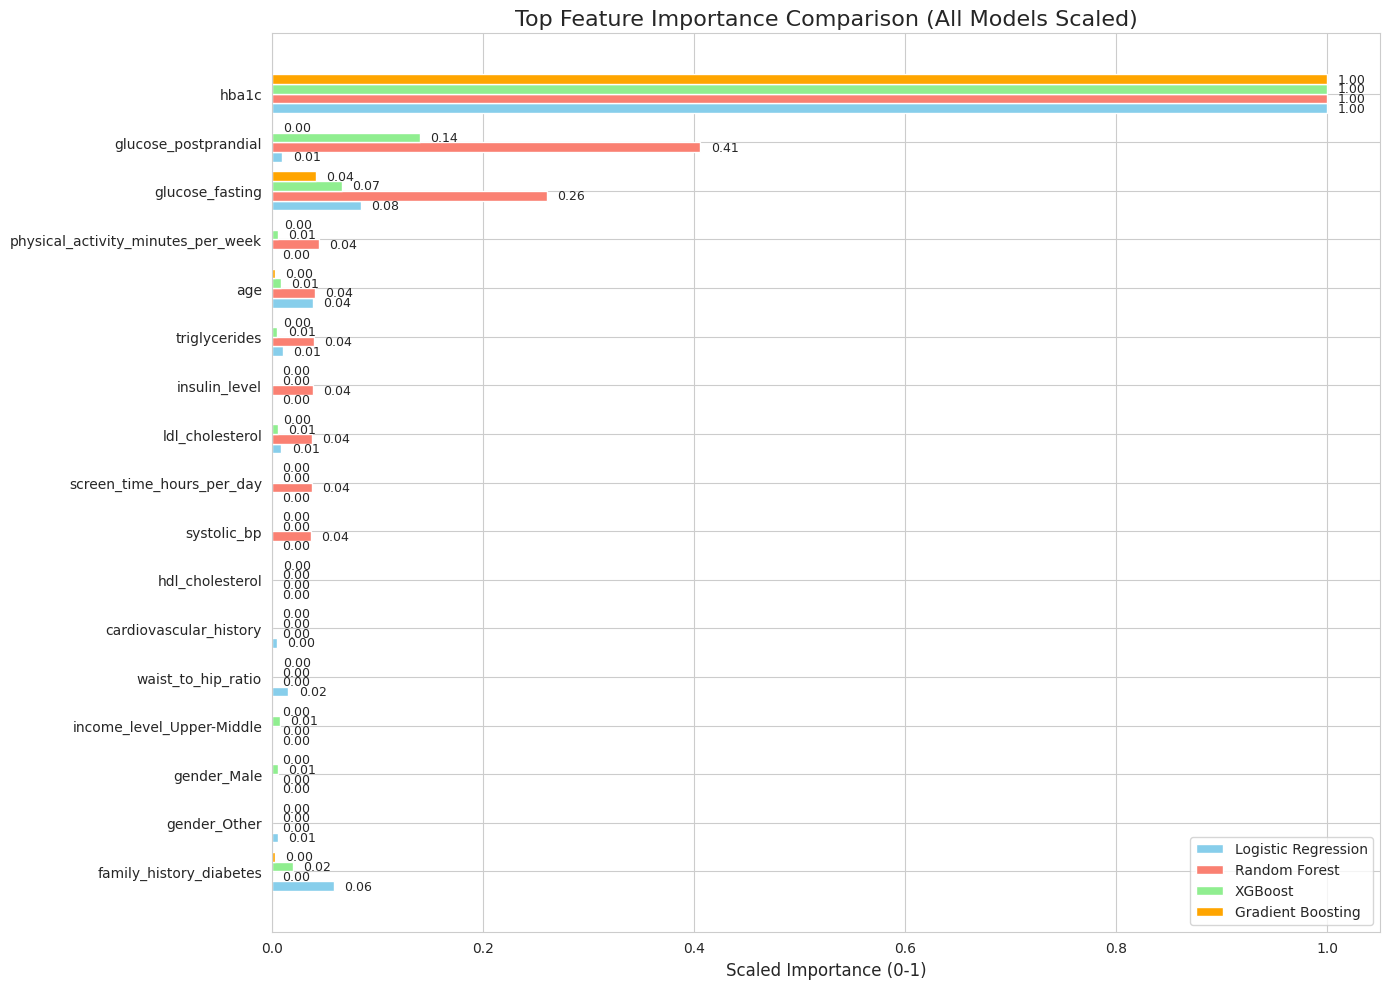

In [32]:
# Scale each model's importance to [0,1] for comparability
importance_df_scaled = importance_df.copy()
importance_df_scaled["Logistic_Regression"] = importance_df_scaled["Logistic_Regression"] / importance_df_scaled["Logistic_Regression"].max()
importance_df_scaled["Random_Forest"] = importance_df_scaled["Random_Forest"] / importance_df_scaled["Random_Forest"].max()
importance_df_scaled["XGBoost"] = importance_df_scaled["XGBoost"] / importance_df_scaled["XGBoost"].max()
importance_df_scaled["GradientBoost"] = importance_df_scaled["GradientBoost"] / importance_df_scaled["GradientBoost"].max()

# Sort features by Random Forest (or any model) for better visualization
importance_df_sorted = importance_df_scaled.sort_values(by="Random_Forest", ascending=True)

# Horizontal bar positions
y_pos = np.arange(len(importance_df_sorted))
height = 0.2  # bar thickness

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Logistic Regression
plt.barh(y_pos - 1.5*height, 
         importance_df_sorted["Logistic_Regression"], 
         height=height, 
         color='skyblue', 
         label='Logistic Regression')

# Random Forest
plt.barh(y_pos - 0.5*height, 
         importance_df_sorted["Random_Forest"], 
         height=height, 
         color='salmon', 
         label='Random Forest')

# XGBoost
plt.barh(y_pos + 0.5*height, 
         importance_df_sorted["XGBoost"], 
         height=height, 
         color='lightgreen', 
         label='XGBoost')

# Gradient Boosting
plt.barh(y_pos + 1.5*height, 
         importance_df_sorted["GradientBoost"], 
         height=height, 
         color='orange', 
         label='Gradient Boosting')

# Add data labels
for i, (lr_val, rf_val, xg_val, gb_val) in enumerate(zip(
    importance_df_sorted["Logistic_Regression"],
    importance_df_sorted["Random_Forest"],
    importance_df_sorted["XGBoost"],
    importance_df_sorted["GradientBoost"]
)):
    plt.text(lr_val + 0.01, i - 1.5*height, f'{lr_val:.2f}', va='center', fontsize=9)
    plt.text(rf_val + 0.01, i - 0.5*height, f'{rf_val:.2f}', va='center', fontsize=9)
    plt.text(xg_val + 0.01, i + 0.5*height, f'{xg_val:.2f}', va='center', fontsize=9)
    plt.text(gb_val + 0.01, i + 1.5*height, f'{gb_val:.2f}', va='center', fontsize=9)

# Set y-ticks and labels
plt.yticks(y_pos, importance_df_sorted.index)
plt.xlabel("Scaled Importance (0-1)", fontsize=12)
plt.title("Top Feature Importance Comparison (All Models Scaled)", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
# Modal Comparison Summary
print("\nFinal Model Selection Summary:")
for model in models.keys():
    print(f"{model} - Accuracy: {models[model]:.4f}, F1 Score: {f1_scores[model]:.4f}, ROC AUC: {roc_auc_scores[model]:.4f}")



Final Model Selection Summary:
Decision Tree - Accuracy: 0.8629, F1 Score: 0.8866, ROC AUC: 0.8555
Random Forest - Accuracy: 0.9196, F1 Score: 0.9282, ROC AUC: 0.9410
GradientBoost - Accuracy: 0.9199, F1 Score: 0.9285, ROC AUC: 0.9447
Logistic Regression - Accuracy: 0.8605, F1 Score: 0.8850, ROC AUC: 0.9338
XgBoost - Accuracy: 0.9199, F1 Score: 0.9285, ROC AUC: 0.9432


Decent performance (≈86% accuracy), but not strong enough for complex medical cases.
Good intuition (ROC-AUC ≈0.93), but still not the best.

2️⃣ Decision Tree

A fast learner, but often jumps to conclusions.
Accuracy ≈86% — similar to Logistic Regression.
Not reliable enough for medical diagnosis.

3️⃣ Random Forest

A team of decision trees working together.
Much stronger: accuracy ≈92%, great balance, and strong medical intuition.
A dependable and trustworthy model.

4️⃣ XGBoost

Like a very clever specialist who learns from mistakes quickly.
Accuracy ≈92%, F1 ≈0.93, ROC-AUC ≈0.94+.
Very stable, sharp, and consistent.

5️⃣ Gradient Boosting

The most methodical and patient model.
It slowly corrects itself and becomes extremely accurate.
Accuracy ≈92%, F1 ≈0.93, ROC-AUC ≈0.946
(the highest of all models).

### Cross Validation For All the Models 

In [34]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [35]:
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        objective='binary:logistic',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    "Gradient_Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [38]:
# Store results
cv_results_list = []

for name, model in models.items():
    print(f"Running CV for {name}...")
    
    # Accuracy
    acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    
    # F1 Score
    f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    
    # ROC-AUC
    roc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    
    # Append as dict to list
    cv_results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC_AUC": roc
    })

# Convert list of dicts to DataFrame
cv_results = pd.DataFrame(cv_results_list)
cv_results


Running CV for Logistic_Regression...


Running CV for Random_Forest...
Running CV for XGBoost...
Running CV for Gradient_Boosting...


,Model,Accuracy,F1,ROC_AUC
0,Logistic_Regression,0.858900,0.883786,0.933982
1,Random_Forest,0.921300,0.929827,0.943344
2,XGBoost,0.921388,0.929898,0.945205
3,Gradient_Boosting,0.921400,0.929905,0.946616


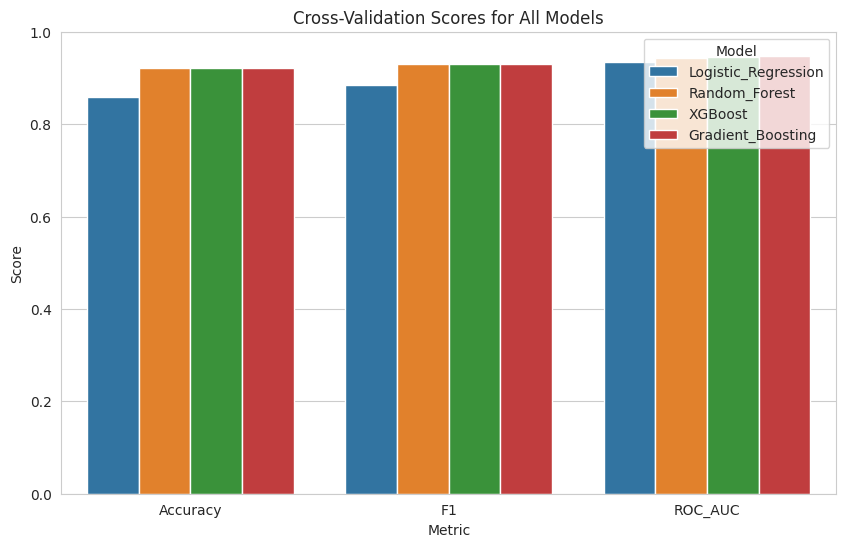

In [39]:
cv_results_melted = cv_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Metric", y="Score", hue="Model", data=cv_results_melted)
plt.title("Cross-Validation Scores for All Models")
plt.ylim(0,1)
plt.ylabel("Score")
plt.show()

Based on the cross-validation results, Gradient Boosting emerged as the most reliable and accurate model for predicting diabetes diagnoses. While Random Forest and XGBoost also demonstrated strong performance, Gradient Boosting consistently achieved the highest values across all key evaluation metrics, including Accuracy, F1 Score, and ROC-AUC. This indicates that it not only predicts correctly more often but also balances false positives and false negatives effectively and distinguishes diabetic from non-diabetic cases with superior confidence. Therefore, Gradient Boosting is selected as the final model due to its overall stability, predictive strength, and suitability for medical classification tasks.